# parametre değişimi sonuçlarının tutlacağı dosya için

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
# Correcting the filename to match the uploaded file
log = pd.read_csv('experiment_log_distilbert .csv')
log

Saving experiment_log_distilbert .csv to experiment_log_distilbert  (2).csv


,exp_name,model,learning_rate,batch_size,epochs,class_weights,test_precision,test_recall,test_f1,test_accuracy,test_pr_auc,test_roc_auc,test_loss
0,distilbert_weighted_v1,distilbert-base-uncased,0.00006,8,3,balanced,0.761108,0.747594,0.753139,0.747594,0.590813,0.778573,0.532429
1,distilbert_weighted_v1,distilbert-base-uncased,0.00006,8,3,balanced,0.754017,0.759674,0.756533,0.759674,0.555617,0.764501,0.561315
2,distilbert_weighted_v1,distilbert-base-uncased,0.00001,8,4,balanced,0.747675,0.760267,0.752157,0.760267,0.506795,0.736367,0.672554
3,distilbert_weighted_v1,distilbert-base-uncased,0.00002,8,6,balanced,0.760431,0.768597,0.763731,0.768597,0.585466,0.773064,0.520297


In [ ]:
LOG_FILE = "experiment_log_distilbert.csv"

import os
import pandas as pd

# Eğer dosya yoksa başlık satırı oluştursun
if not os.path.exists(LOG_FILE):
    pd.DataFrame(columns=[
        "exp_name",
        "model",
        "learning_rate",
        "batch_size",
        "epochs",
        "class_weights",
        "test_precision",
        "test_recall",
        "test_f1",
        "test_accuracy",
        "test_pr_auc",
        "test_roc_auc",
        "test_loss"
    ]).to_csv(LOG_FILE, index=False)

def log_experiment(exp_name, model_name, lr, batch_size, epochs, test_loss, test_precision, test_recall, test_f1, test_accuracy, test_pr_auc, test_roc_auc, class_weights):
    new_row = pd.DataFrame([{
        "exp_name": exp_name,
        "model": model_name,
        "learning_rate": lr,
        "batch_size": batch_size,
        "epochs": epochs,
        "class_weights": class_weights,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1": test_f1,
        "test_accuracy": test_accuracy,
        "test_pr_auc": test_pr_auc,
        "test_roc_auc": test_roc_auc,
        "test_loss": test_loss
    }])
    new_row.to_csv(LOG_FILE, mode='a', header=not os.path.exists(LOG_FILE), index=False)
    print(f"✅ Deney kaydedildi: {LOG_FILE}")

In [ ]:
!pip install -q transformers datasets scikit-learn accelerate



In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch
import numpy as np
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, f1_score, accuracy_score


In [ ]:
from google.colab import files

# Bilgisayarından kaggle.json seç
uploaded = files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Dataset'i indir
!kaggle datasets download -d rmisra/imdb-spoiler-dataset -q
!unzip -n imdb-spoiler-dataset.zip -d data > /dev/null

!ls -lh data


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/rmisra/imdb-spoiler-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
total 922M
-rw-r--r-- 1 root root  14M Oct 24  2019 IMDB_movie_details.json
-rw-r--r-- 1 root root 909M Oct 24  2019 IMDB_reviews.json


In [ ]:
import pandas as pd
import numpy as np
import ast
import re

REVIEWS = "data/IMDB_reviews.json"
DETAILS = "data/IMDB_movie_details.json"

df_reviews = pd.read_json(REVIEWS, lines=True)
df_details = pd.read_json(DETAILS, lines=True)

print("Yorumlar:", df_reviews.shape, " | Filmler:", df_details.shape)

def to_list(x):
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return []

df_details["genre"] = df_details["genre"].apply(to_list)

df = df_reviews.merge(
    df_details[["movie_id", "genre", "rating", "release_date"]],
    on="movie_id",
    how="left"
)

# Boş / gereksiz kayıtları at
df = df.dropna(subset=["review_text", "is_spoiler"])
df = df[df["review_text"].str.strip() != ""]

print("Birleşik tablo boyutu:", df.shape)
df.head()


Yorumlar: (573913, 7)  | Filmler: (1572, 7)
Birleşik tablo boyutu: (573913, 10)


,review_date,movie_id,user_id,is_spoiler,review_text,rating_x,review_summary,genre,rating_y,release_date
0,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.,"[Crime, Drama]",9.3,1994-10-14
1,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.,"[Crime, Drama]",9.3,1994-10-14
2,3 August 2001,tt0111161,ur1285640,True,I believe that this film is the best story eve...,8,The best story ever told on film,"[Crime, Drama]",9.3,1994-10-14
3,1 September 2002,tt0111161,ur1003471,True,"**Yes, there are SPOILERS here**This film has ...",10,Busy dying or busy living?,"[Crime, Drama]",9.3,1994-10-14
4,20 May 2004,tt0111161,ur0226855,True,At the heart of this extraordinary movie is a ...,8,"Great story, wondrously told and acted","[Crime, Drama]",9.3,1994-10-14


In [ ]:
import numpy as np

movies = df['movie_id'].drop_duplicates().sample(frac=1, random_state=42).values
n = len(movies)
train_m, val_m, test_m = np.split(movies, [int(.7*n), int(.85*n)])

def mark(m): return df['movie_id'].isin(m)
df.loc[mark(train_m),'split']='train'
df.loc[mark(val_m),'split']='val'
df.loc[mark(test_m),'split']='test'

train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()


In [ ]:
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

# label'ları int (0/1) yap
train_df["is_spoiler"] = train_df["is_spoiler"].astype(int)
val_df["is_spoiler"]   = val_df["is_spoiler"].astype(int)
test_df["is_spoiler"]  = test_df["is_spoiler"].astype(int)

print(train_df["is_spoiler"].dtype, val_df["is_spoiler"].dtype, test_df["is_spoiler"].dtype)


len(train_df), len(val_df), len(test_df)

int64 int64 int64


(406836, 82804, 84273)

In [ ]:
from datasets import Dataset, Value
from transformers import DistilBertTokenizerFast


tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
max_length = 512

# 1) Pandas DF -> HF Dataset
train_ds = Dataset.from_pandas(train_df[["review_text", "is_spoiler"]])
val_ds   = Dataset.from_pandas(val_df[["review_text", "is_spoiler"]])
test_ds  = Dataset.from_pandas(test_df[["review_text", "is_spoiler"]])

# 2) labels int yap (0/1)
train_ds = train_ds.rename_column("is_spoiler", "labels")
val_ds   = val_ds.rename_column("is_spoiler", "labels")
test_ds  = test_ds.rename_column("is_spoiler", "labels")

# int tipine zorla
train_ds = train_ds.cast_column("labels", Value("int64"))
val_ds   = val_ds.cast_column("labels", Value("int64"))
test_ds  = test_ds.cast_column("labels", Value("int64"))

# 3) Tokenization
def tokenize_function(batch):
    return tokenizer(
        batch["review_text"],
        padding="max_length",
        truncation=True,
        max_length=max_length
    )

train_ds = train_ds.map(tokenize_function, batched=True)
val_ds   = val_ds.map(tokenize_function, batched=True)
test_ds  = test_ds.map(tokenize_function, batched=True)

# 4) Gereksiz kolonları at
cols_to_keep = ["input_ids", "attention_mask", "labels"]
train_ds = train_ds.remove_columns([c for c in train_ds.column_names if c not in cols_to_keep])
val_ds   = val_ds.remove_columns([c for c in val_ds.column_names if c not in cols_to_keep])
test_ds  = test_ds.remove_columns([c for c in test_ds.column_names if c not in cols_to_keep])

# 5) PyTorch format
train_ds.set_format("torch")
val_ds.set_format("torch")
test_ds.set_format("torch")

train_ds[0]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Casting the dataset:   0%|          | 0/84273 [00:00<?, ? examples/s]

Map:   0%|          | 0/406836 [00:00<?, ? examples/s]

Map:   0%|          | 0/82804 [00:00<?, ? examples/s]

Map:   0%|          | 0/84273 [00:00<?, ? examples/s]

{'labels': tensor(1),
 'input_ids': tensor([  101,  1999,  2049,  7436,  2095,  1010,  8233,  9688,  2243, 18434,
          1006,  2517,  1998,  2856,  2011,  3581, 18243,  7875, 12162,  1010,
          2044,  1996, 20674, 11620, 10974,  5172,  1998,  1996,  8233,  9688,
          2243, 18434,  1010,  2011,  4459,  2332,  1007,  2001,  4222,  2005,
          2698,  2914,  2982,  1010,  1998,  2939,  2185,  2007,  5717,  1012,
          2190,  3861,  2253,  2000, 16319, 16031,  2361,  1010,  2096,  8233,
          9688,  2243,  1998, 16016,  4349,  2020,  1000,  2074,  3407,  2000,
          2022,  4222,  1012,  1000,  1997,  2607, 17666, 25807,  2003,  2322,
          1013,  2322,  1010,  2021,  2096,  2381,  3504,  2067,  2006, 16031,
          2361,  2004,  1037,  2204,  2143,  1010, 16016,  1998, 18434,  2024,
          4622,  2004,  2070,  1997,  1996,  2035,  1011,  2051,  2190,  1012,
         16016,  1010,  2174,  1010,  2001,  1037,  3112,  2013,  1996,  2773,
          1000,  

In [ ]:
train_ds = train_ds.shuffle(seed=42)


In [ ]:
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    labels = np.array(labels)

    # Probabilities for class 1
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    preds = (probs >= 0.5).astype(int)

    # LSTM'deki gibi: weighted precision / recall / F1
    precision = precision_score(labels, preds, average="weighted", zero_division=0)
    recall    = recall_score(labels, preds, average="weighted", zero_division=0)
    f1        = f1_score(labels, preds, average="weighted")
    accuracy  = accuracy_score(labels, preds)

    # Ek olarak ROC-AUC ve PR-AUC de hesaplayalım
    pr_prec, pr_rec, _ = precision_recall_curve(labels, probs)
    pr_auc   = auc(pr_rec, pr_prec)
    roc_auc  = roc_auc_score(labels, probs)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
    }

In [ ]:
checkpoint = "prajjwal1/bert-tiny"



In [ ]:

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

# train_ds: HF Dataset, içinde "labels" kolonu var
y_train = np.array(train_ds["labels"])  # 0/1 etiketler

class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)

print("Class weights (numpy):", class_weights_np)

# Torch tensöre çevir
class_weights = torch.tensor(class_weights_np, dtype=torch.float)
print("Class weights (torch):", class_weights)


Class weights (numpy): [0.67990026 1.88965889]
Class weights (torch): tensor([0.6799, 1.8897])


In [ ]:
batch_size = 4



In [ ]:
from transformers import Trainer
import torch.nn as nn

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=0):
        # Trainer'ın beklediği imza: (model, inputs, return_outputs=False)
        labels = inputs.pop("labels")

        # Model forward
        outputs = model(**inputs)
        logits = outputs.logits  # [batch_size, num_labels]

        # Cihaz ayarı
        device = logits.device
        labels = labels.to(device)
        weights = self.class_weights.to(device)

        # İkili sınıflandırma: CrossEntropyLoss kullanıyoruz (num_labels=2)
        loss_fct = nn.CrossEntropyLoss(
            weight=weights if weights is not None else None
        )
        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1).long()
        )

        if return_outputs:
            return loss, outputs
        return loss

In [ ]:
epoch      = 10
learn_rate = 1e-5
weight_dec = 0.02


training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/spoiler_project/checkpoints_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    max_grad_norm=5.0,            # ← Gradient clipping (LSTM'dekiyle aynı fikir)
    num_train_epochs=epoch,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    learning_rate=learn_rate,
    weight_decay=weight_dec,
    logging_steps=500,
    report_to="none",
)

from transformers import EarlyStoppingCallback

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=4,
        early_stopping_threshold=1e-4
    )]
)


import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "offline"



In [ ]:

trainer.train()
# eval_f1 içeren logları filtrele
eval_logs = [log for log in trainer.state.log_history if "eval_f1" in log]

best_log = max(eval_logs, key=lambda x: x["eval_f1"])
best_epoch = int(best_log["epoch"])
best_val_f1 = best_log["eval_f1"]

print(f"Best epoch (by eval_f1): {best_epoch}, eval_f1 = {best_val_f1:.4f}")

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Pr Auc,Roc Auc
1,0.573200,0.495869,0.761422,0.771279,0.765122,0.771279,0.574950,0.777968
2,0.580200,0.489457,0.767201,0.780264,0.770798,0.780264,0.588572,0.784085
3,0.556100,0.508192,0.766546,0.770241,0.768248,0.770241,0.591016,0.785139
4,0.531800,0.510085,0.766482,0.774999,0.769803,0.774999,0.589713,0.782946
5,0.560800,0.511051,0.766448,0.773634,0.769414,0.773634,0.588129,0.784133
6,0.561000,0.525194,0.767687,0.783356,0.769983,0.783356,0.587132,0.780710


Best epoch (by eval_f1): 2, eval_f1 = 0.7708


In [ ]:
train_losses_epoch = {}
val_losses_epoch   = {}
val_f1_epoch       = {}

for log in trainer.state.log_history:
    # TRAIN loss (step-level, epoch'a göre grupla)
    if "loss" in log and "epoch" in log and "eval_loss" not in log:
        ep = int(log["epoch"])
        train_losses_epoch.setdefault(ep, []).append(log["loss"])

    # VALIDATION loss & F1 (epoch-level)
    if "eval_loss" in log:
        ep = int(log["epoch"])
        val_losses_epoch[ep] = log["eval_loss"]
        val_f1_epoch[ep]     = log.get("eval_f1", None)
epochs = sorted(val_losses_epoch.keys())

train_loss_list = []
val_loss_list   = []
val_f1_list     = []

for ep in epochs:
    # o epoch'taki train loss'ların ortalaması
    if ep in train_losses_epoch:
        avg_train_loss = sum(train_losses_epoch[ep]) / len(train_losses_epoch[ep])
    else:
        avg_train_loss = None

    train_loss_list.append(avg_train_loss)
    val_loss_list.append(val_losses_epoch[ep])
    val_f1_list.append(val_f1_epoch[ep])


In [ ]:
# ----------------------
# TEST SETİNDE DEĞERLENDİR VE LOG'A YAZ
# ----------------------
test_metrics = trainer.evaluate(test_ds)

test_loss      = test_metrics["eval_loss"]
test_precision = test_metrics["eval_precision"]
test_recall    = test_metrics["eval_recall"]
test_f1        = test_metrics["eval_f1"]
test_accuracy  = test_metrics["eval_accuracy"]
test_pr_auc    = test_metrics["eval_pr_auc"]
test_roc_auc   = test_metrics["eval_roc_auc"]

print("---- TEST (DistilBERT) ----")
print(f"Loss:       {test_loss:.4f}")
print(f"Precision:  {test_precision:.4f}")
print(f"Recall:     {test_recall:.4f}")
print(f"F1-score:   {test_f1:.4f}")
print(f"Accuracy:   {test_accuracy:.4f}")
print(f"PR-AUC:     {test_pr_auc:.4f}")
print(f"ROC-AUC:    {test_roc_auc:.4f}")


log_experiment(
    exp_name      = "distilbert_weighted_v1",
    model_name    = "distilbert-base-uncased",
    lr            = learn_rate,
    batch_size    = batch_size,
    epochs        = best_epoch,
    test_loss     = test_loss,
    test_precision= test_precision,
    test_recall   = test_recall,
    test_pr_auc   = test_pr_auc,
    test_roc_auc  = test_roc_auc,
    test_f1 = test_f1,
    test_accuracy = test_accuracy,
    class_weights = "balanced"
)

---- TEST (DistilBERT) ----
Loss:       0.4936
Precision:  0.7657
Recall:     0.7786
F1-score:   0.7693
Accuracy:   0.7786
PR-AUC:     0.5895
ROC-AUC:    0.7819
✅ Deney kaydedildi: experiment_log_distilbert.csv


In [ ]:
# En iyi modeli kaydet (KLASÖRE!)
MODEL_DIR = "models/distilbert_weighted_v1"  # csv değil, klasör adı

trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print(f"\n✅ Model kaydedildi: {MODEL_DIR}")



✅ Model kaydedildi: models/distilbert_weighted_v1


f1 learning curve

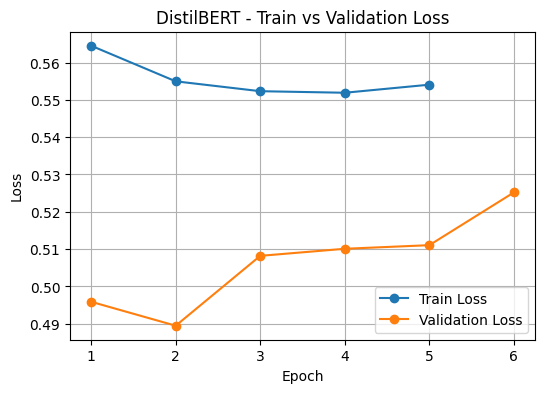

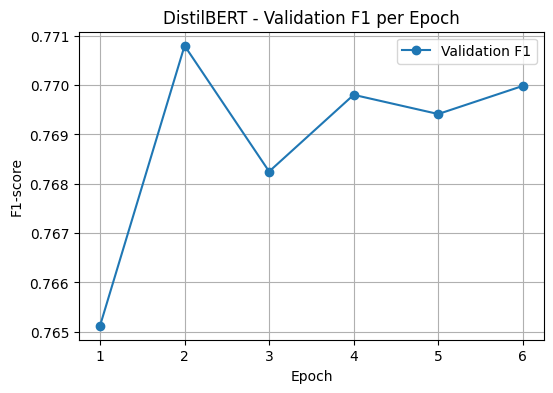

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss_list, label="Train Loss", marker="o")
plt.plot(epochs, val_loss_list,   label="Validation Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilBERT - Train vs Validation Loss")
plt.legend()
plt.grid()
plt.savefig("distilbert_train_val_loss.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, val_f1_list, label="Validation F1", marker="o")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("DistilBERT - Validation F1 per Epoch")
plt.legend()
plt.grid()
plt.savefig("distilbert_val_f1.png", dpi=300, bbox_inches="tight")
plt.show()


ROC Curve + AUC

DistilBERT Test AUC: 0.7819359620880186


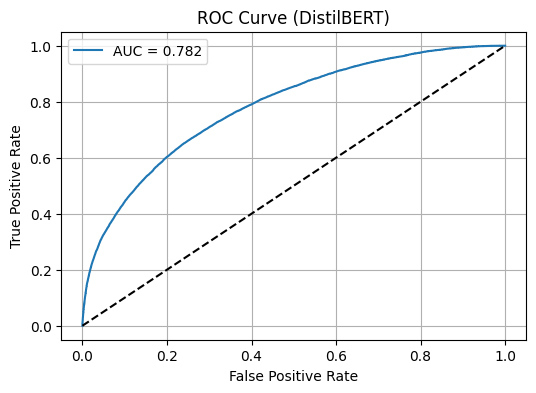

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np

# HF Trainer ile test set üzerinde tahmin al
preds = trainer.predict(test_ds)

logits = preds.predictions      # shape: (N, 2)
true_labels = preds.label_ids   # shape: (N,)

# class=1 için olasılıkları hesapla
probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

# ROC eğrisi ve AUC
fpr, tpr, thresholds = roc_curve(true_labels, probs)
auc_score = auc(fpr, tpr)

print("DistilBERT Test AUC:", auc_score)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (DistilBERT)")
plt.legend()
plt.grid()
plt.savefig("distilbert_roc.png", dpi=300, bbox_inches="tight")    # KAYDET
plt.show()


confisoun matrix

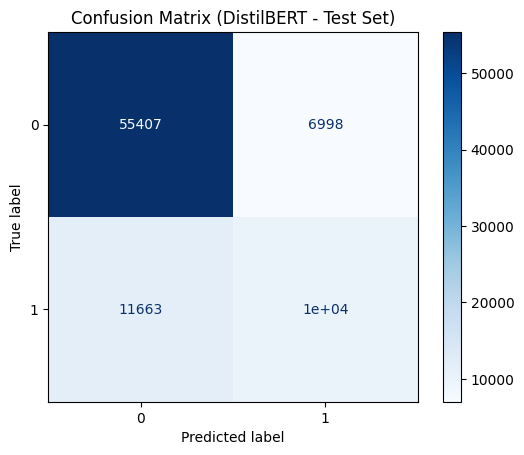

Confusion Matrix:
[[55407  6998]
 [11663 10205]]


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import torch

# Test set üzerinde tahmin al
preds = trainer.predict(test_ds)

logits = preds.predictions          # (N, 2)
true_labels = preds.label_ids       # (N,)

# Softmax olasılıklarını hesapla
probs = torch.softmax(torch.tensor(logits), dim=-1)

# En yüksek olasılıklı sınıf (0/1)
all_preds = probs.argmax(dim=1).numpy()

# Confusion Matrix
cm = confusion_matrix(true_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (DistilBERT - Test Set)")
plt.grid(False)
plt.savefig("distilbert_confusionmatrix.png", dpi=300, bbox_inches="tight")    # KAYDET
plt.show()

print("Confusion Matrix:")
print(cm)


fazla yazım durumunda silim için

In [ ]:
from google.colab import files
files.download("experiment_log_distilbert.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>